In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [14]:
dataset_name = 'Estrella_full'; natural_dataset=False
# dataset_name = 'Grilli.Soil'; natural_dataset=True
# dataset_name = 'Goldford.Leucine'; natural_dataset = False
# dataset_name = 'Goldford.Citrate'; natural_dataset = False
# dataset_name = 'Goldford.Glucose'; natural_dataset = False
# dataset_name = 'Goldford.complete_dataset'; natural_dataset = False

with open('out/{}/low_variance_eigenmodes.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    low_variance_eigenmodes = pickle.load(f)
    f.close()
with open('out/{}/eigvects.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    eigvects = pickle.load(f)
    f.close()
with open('out/{}/family_tags.filtered.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    family_tags = pickle.load(f); family_tags = np.array(family_tags)
    if 'Goldford' in dataset_name:
        new_tags = [tag.split(':')[0] for tag in family_tags]
        family_tags = np.array(new_tags)

with open('out/{}/full_dataset.filtered.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    full_dataset = pickle.load(f);

In [15]:
print(np.shape(full_dataset))

(276, 14)


In [18]:
which_mode = 0
mode = low_variance_eigenmodes[:,which_mode]

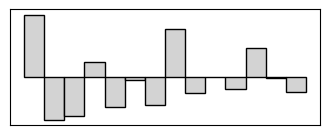

In [19]:
set_xticks = False
if set_xticks==False: figsize=(4,1.5)
else: figsize = (4,2)

plot_tags_as_ticks = False
if natural_dataset==True:
    edgecolor=None
    facecolor='gray'
    figsize= (8,2)
    plot_tags = True
    how_many_tags_to_plot = 5
    rotate = False; angle = 0
else:
    edgecolor='k'
    facecolor='lightgray'
    plot_tags = False

if 'Goldford' in dataset_name:
    figsize=(5,2)
    plot_tags = True
    how_many_tags_to_plot = 20
    rotate = True; angle=45
    plot_tags_as_ticks = True
    if 'complete_dataset' in dataset_name:
        how_many_tags_to_plot = 2
        angle = 0
    

fig,ax = plt.subplots(figsize=figsize)
ax.bar(np.arange(len(mode)),
       mode,width=1,
       edgecolor=edgecolor,
       facecolor=facecolor,
      )
ax.set_yticks([])
if set_xticks==False:
    ax.set_xticks([])
if plot_tags and plot_tags_as_ticks==False:
    argsorted_loadings = np.flip(np.argsort(np.abs(mode)))
    # argsorted_loadings = np.where(family_tags[:np.shape(low_variance_eigenmodes)[1]]=='g__Ralstonia')[0]
    argsorted_loadings = argsorted_loadings[:how_many_tags_to_plot]
    labels = family_tags[argsorted_loadings]
    # ax.set_xticks(argsorted_loadings)
    # ax.set_xticklabels(labels,rotation=-30,ha='left')
    # text_adjustments = np.array([0,-0.0,-0.04,-0.07,0]) #mode 1
    text_adjustments = np.array([0,0,0,0,0])
    text_adjustments = np.zeros(how_many_tags_to_plot)
    for i,load in enumerate(argsorted_loadings):
        print(load,mode[load])
        ax.text(load,
               # (mode[load])+0.05*(i==1)-0.05*(i==4) ,#Mode 0,
               mode[load]+0.1*np.sign(mode[load])+text_adjustments[i], #Mode 1,
                s=labels[i],
                fontsize=12,
               rotation = np.sign(mode[load])*angle,rotation_mode='anchor')
if plot_tags_as_ticks:
    argsorted_loadings = np.flip(np.argsort(np.abs(mode)))
    argsorted_loadings = argsorted_loadings[:how_many_tags_to_plot]
    print(argsorted_loadings)
    labels = family_tags[argsorted_loadings]
    bot_labels = []; bot_ticks = []
    top_labels = []; top_ticks = []
    for i,load in enumerate(argsorted_loadings):
        sign = np.sign(mode[load])
        if sign>0:
            print(i,load)
            top_ticks.append(load)
            top_labels.append(labels[i])
        else:
            bot_ticks.append(load)
            bot_labels.append(labels[i])

    ax2 = ax.twiny()
    ax.set_xticks(bot_ticks)
    ax.set_xticklabels(bot_labels,rotation = -angle,ha='left')
    ax2.set_xticks(top_ticks)
    ax2.set_xticklabels(top_labels,rotation=angle,ha='left')
    ax2.set_xlim(ax.get_xlim())

# ax.set_xticks(range(len(family_tags)))
# ax2.set_xticks(range(len(family_tags)))
if natural_dataset:
    ax.axis('off')
format = 'svg'
plt.savefig('individual_eigenvectors/low_variance_mode.{}.{}.{}'.format(which_mode,dataset_name,format),transparent=True,format=format)
format = 'png'
plt.savefig('individual_eigenvectors/low_variance_mode.{}.{}.{}'.format(which_mode,dataset_name,format),transparent=True,format=format)

In [28]:
%matplotlib inline
plt.close('all')